In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.feature_engineering import build_feature_vector, heuristic_label

DATA_PATH = ROOT / "data" / "raw" / "kt1_merged.csv"
OUT_PATH = ROOT / "data" / "labeled_sessions.parquet"
df = pd.read_csv(DATA_PATH)
df.head()

,student_id,content_id,correct,time_taken_ms,timestamp,scroll_depth,hint_count,reread_count,exit_flag
0,1,q5012,0,38000,1565096190868,100,0,0,0
1,2,q4706,1,24000,1565096221062,100,0,0,0
2,3,q4366,1,68000,1565096293432,100,0,0,0
3,4,q4829,0,42000,1565096339668,100,0,0,0
4,5,q6528,0,59000,1565096401774,100,0,0,0


In [2]:
def build_labeled_dataset(df):
    rows = []

    grouped = df.groupby(["student_id", "content_id"], dropna=False)

    for (sid, cid), group in grouped:
        events = group.to_dict(orient="records")
        features = build_feature_vector(events)
        label = heuristic_label(features)

        features["student_id"] = sid
        features["content_id"] = cid
        features["strain_level"] = label
        rows.append(features)

    return pd.DataFrame(rows)

labeled_df = build_labeled_dataset(df)
labeled_df.head()

,latency_delta,error_rate,attempt_burst,attention_drop,hint_reliance,cold_start_latency,exit_flag_ratio,reread_normalized,student_id,content_id,strain_level
0,0.0,1.0,0.0,0.0,0.0,38000.0,0.0,0.0,1,q5012,LOW
1,0.0,0.0,0.0,0.0,0.0,24000.0,0.0,0.0,2,q4706,LOW
2,0.0,0.0,0.0,0.0,0.0,68000.0,0.0,0.0,3,q4366,LOW
3,0.0,1.0,0.0,0.0,0.0,42000.0,0.0,0.0,4,q4829,LOW
4,0.0,1.0,0.0,0.0,0.0,59000.0,0.0,0.0,5,q6528,LOW


In [3]:
print("Shape:", labeled_df.shape)
print(labeled_df["strain_level"].value_counts())
print(labeled_df["strain_level"].value_counts(normalize=True))

Shape: (1075, 11)
strain_level
LOW         1072
MODERATE       3
Name: count, dtype: int64
strain_level
LOW         0.997209
MODERATE    0.002791
Name: proportion, dtype: float64


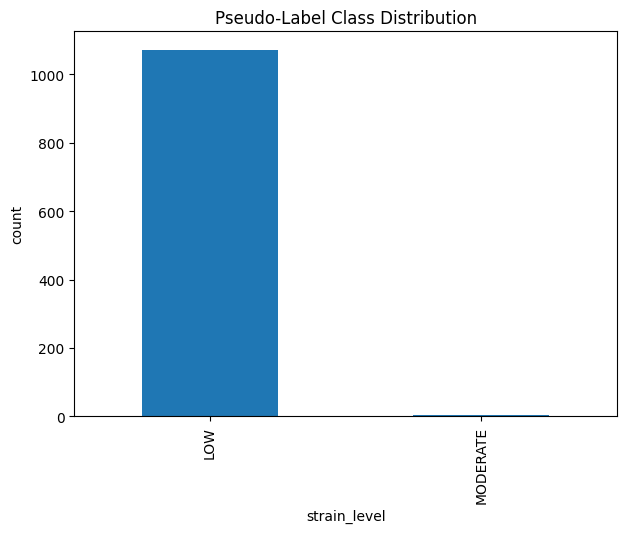

In [4]:
plt.figure(figsize=(7,5))
labeled_df["strain_level"].value_counts().plot(kind="bar")
plt.title("Pseudo-Label Class Distribution")
plt.xlabel("strain_level")
plt.ylabel("count")
plt.show()

In [5]:
feature_cols = [
    "latency_delta",
    "error_rate",
    "attempt_burst",
    "attention_drop",
    "hint_reliance",
    "cold_start_latency",
    "exit_flag_ratio",
    "reread_normalized",
]

labeled_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_delta,1075.0,110.697674,1640.002577,0.0,0.0,0.0,0.0,26375.0
error_rate,1075.0,0.303721,0.459318,0.0,0.0,0.0,1.0,1.0
attempt_burst,1075.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
attention_drop,1075.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
hint_reliance,1075.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
cold_start_latency,1075.0,49831.510698,58491.940361,666.0,25000.0,37000.0,53500.0,1200000.0
exit_flag_ratio,1075.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
reread_normalized,1075.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


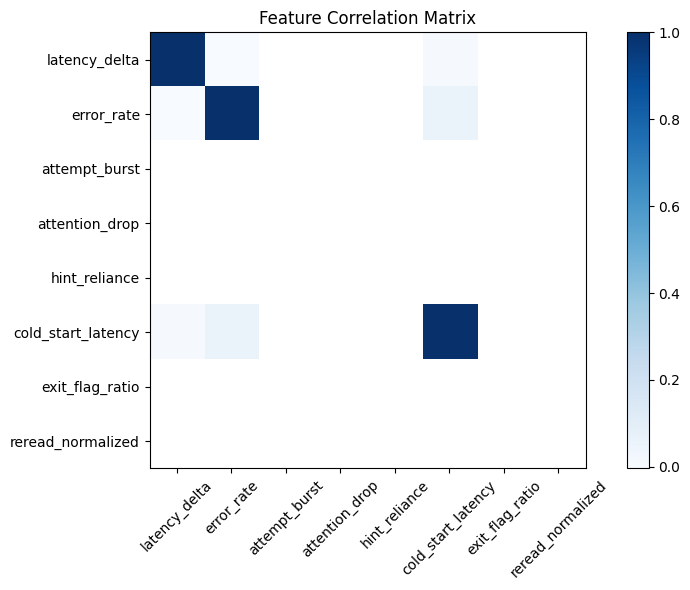

In [6]:
corr = labeled_df[feature_cols].corr()

plt.figure(figsize=(9,6))
plt.imshow(corr, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
labeled_df.to_parquet(OUT_PATH, index=False)
print("Saved to:", OUT_PATH)

Saved to: /Users/jigyasa/Vscode-me/cognio/ml/data/labeled_sessions.parquet


In [8]:
counts = labeled_df["strain_level"].value_counts()
minority_ratio = counts.min() / counts.max()

print("Minority ratio:", round(float(minority_ratio), 4))
if minority_ratio < 0.5:
    print("Class imbalance detected. SMOTE can be applied later during model training.")
else:
    print("Class balance is acceptable for now.")

Minority ratio: 0.0028
Class imbalance detected. SMOTE can be applied later during model training.
